<a href="https://colab.research.google.com/github/KingKouame/KingKouame/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For this task, I have decided to use Google Colab as it is easier to use for me and I am more familiar with the platform.

To get started, first we are importing 'pandas' which will allow us to select data from a dataset.

In [13]:
import pandas as pd
import numpy as np

# for Box-Cox Transformation
from scipy import stats

# Scaling modules
!pip install mlxtend
from mlxtend.preprocessing import minmax_scaling, standardize

# Plotting modules
import seaborn as sns
import matplotlib.pyplot as plt
import missingno


I mount my Google drive which will give me access to the files I upload.

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


To ensure I have the correct file and access to the document, I run the first 5 lines.

In [15]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


To better understand the type of data we are working with, we will first check the size of the data, which also include closely looking at each column.

The dataset has 183 rows and 12 columns.
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex               int8
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin            int16
Embarked          int8
dtype: object


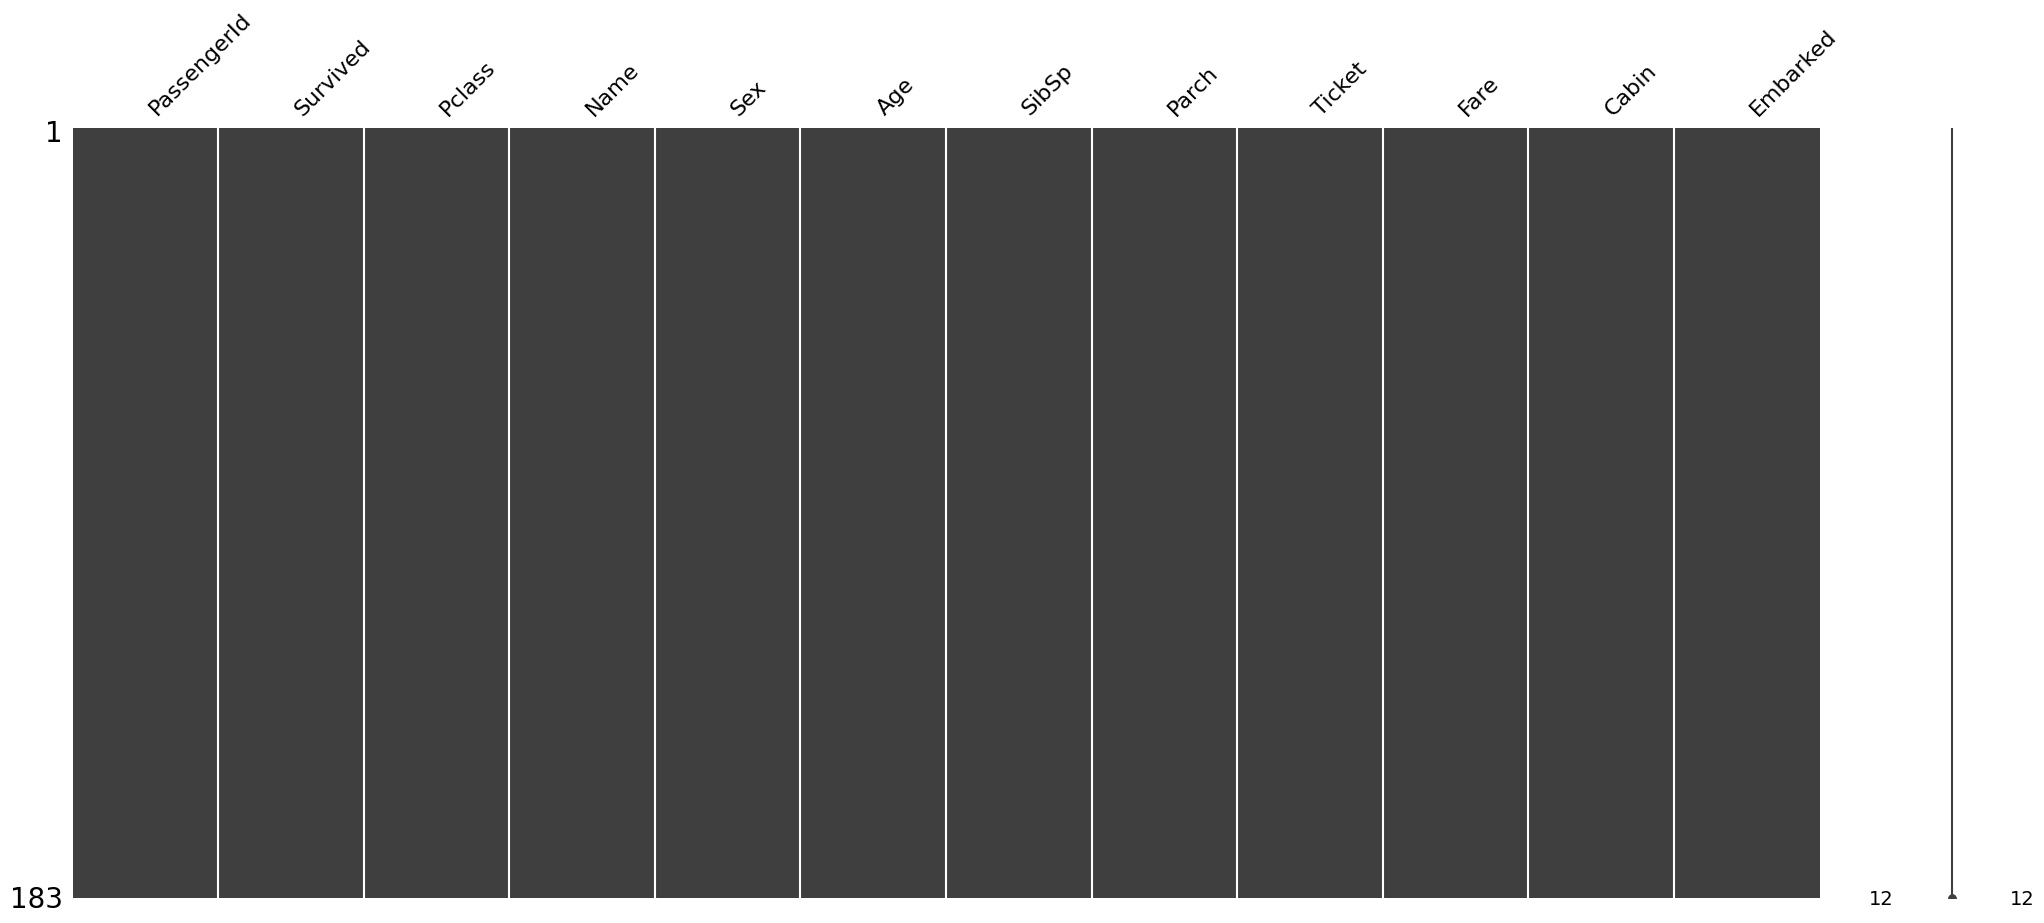

In [26]:
# Data Exploration

# Checking the size of the dataset

print("The dataset has", df.shape[0], "rows and", df.shape[1], "columns.")

# Checking the data types of each column

print(df.dtypes)

# Checking for missing values

missingno.matrix(df)

# Getting the number of missing data points per column.

missing_values_count = df.isnull().sum()


Next, we look at potential outliers. To get us started, we will first clean the data set to get it ready for the analysis. As part of the cleaning, we will remove any discrepancies.

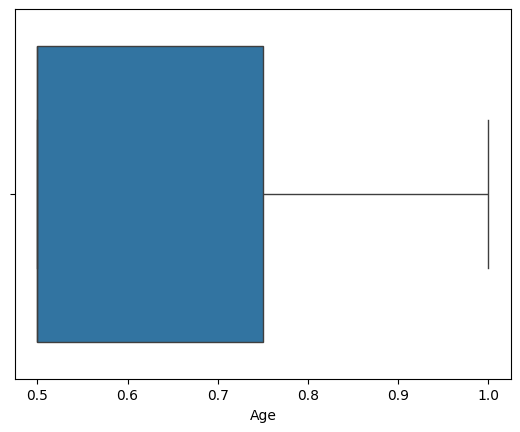

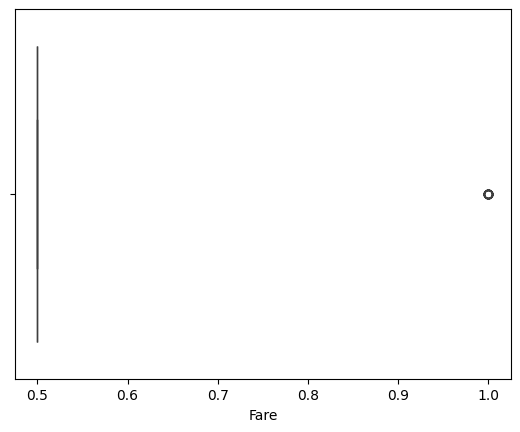

In [27]:
# Dropping missing values.

df = df.dropna()

# Converting categorical variables to numeric.

df['Sex'] = df['Sex'].astype('category').cat.codes
df['Embarked'] = df['Embarked'].astype('category').cat.codes
df['Cabin'] = df['Cabin'].astype('category').cat.codes

# Normalising numeric variables.

df['Age'] = minmax_scaling(df['Age'].values.reshape(-1, 1), columns=[0])
df['Fare'] = minmax_scaling(df['Fare'].values.reshape(-1, 1), columns=[0])

# Standardising numeric variables.

df['Age'] = standardize(df['Age'].ravel())
df['Fare'] = standardize(df['Fare'].ravel())

# Winsorising outliers.

df['Age'] = np.where(df['Age'] < 0.5, 0.5, df['Age'])
df['Age'] = np.where(df['Age'] > 1, 1, df['Age'])
df['Fare'] = np.where(df['Fare'] < 0.5, 0.5, df['Fare'])
df['Fare'] = np.where(df['Fare'] > 1, 1, df['Fare'])

# Checking for outliers.

sns.boxplot(x=df['Age'])
plt.show()
sns.boxplot(x=df['Fare'])
plt.show()

# Scaling numeric variables.

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])


It is important to see what type of data is held in each column and how they compare to each other. As such, we will closely look at the distibution of each column. Once the data is cleaned, we can start to visualise it. This will help us to understand the distribution of the variables and identify any relationships between them. We can create histograms to visualise the distribution of the numerical variables.

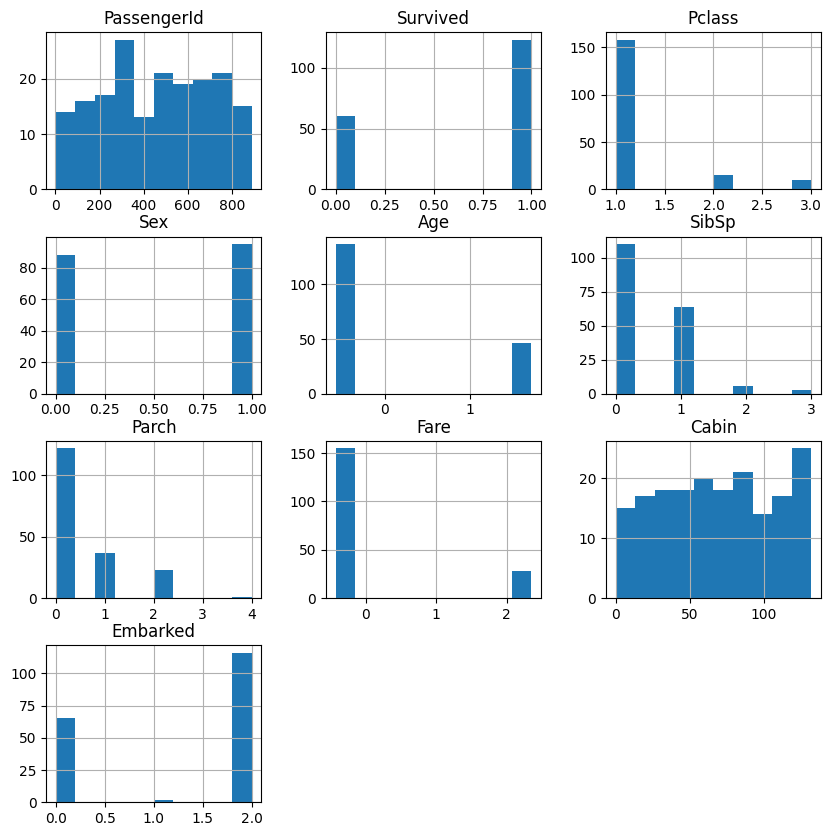

In [28]:
# Checking the distribution of each column

df.hist(figsize=(10, 10), bins=10)
plt.show()

The above histograms will reflect the current data we have and below we will look at a few of them closely.

In [36]:
# The median age of passengers.

median_age = df['Age'].median()
print(f"Median age of passengers: {median_age}")

Median age of passengers: -0.5794535558245064


In [31]:
# The most frequent cabin reserved.

most_frequent_cabin_type = df['Cabin'].value_counts().idxmax()
print(f"Most frequent cabin type: {most_frequent_cabin_type}")

Most frequent cabin type: 131


In [32]:
# The most frequent port of embarkation.

most_frequent_port = df['Embarked'].value_counts().idxmax()
print(f"The most frequent port of embarkation is {most_frequent_port}.")

The most frequent port of embarkation is 2.


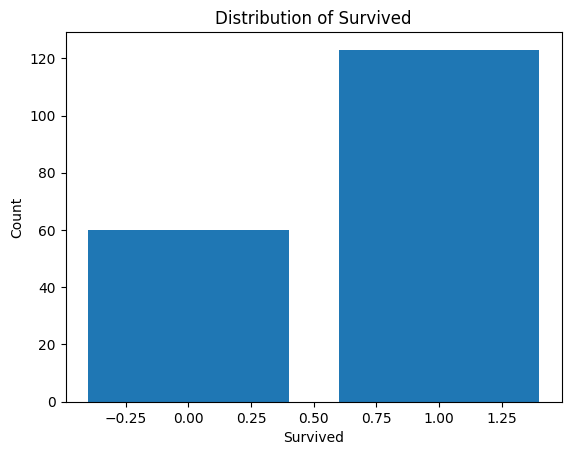

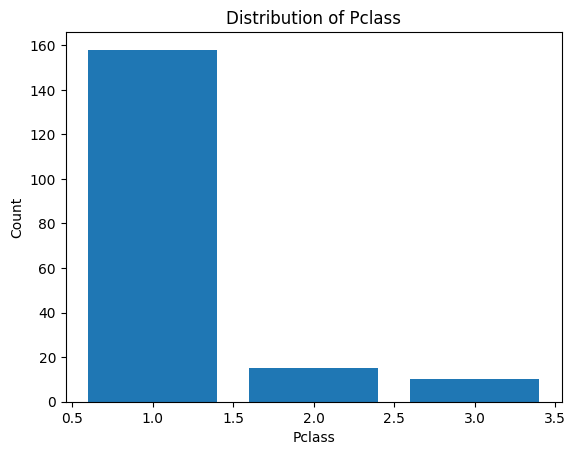

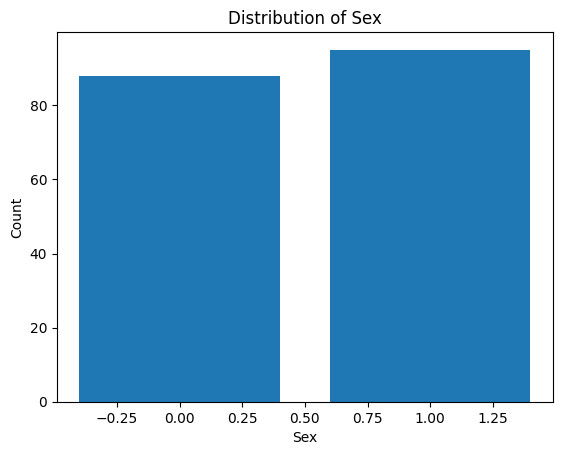

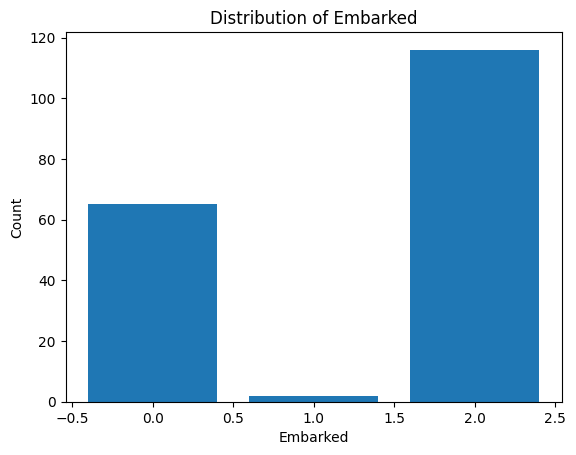

In [48]:
def plot_categorical_distribution(df, column_name):

  counts = df[column_name].value_counts()
  labels = counts.index.to_list()
  values = counts.to_list()

  plt.bar(labels, values)
  plt.xlabel(column_name)
  plt.ylabel("Count")
  plt.title(f"Distribution of {column_name}")
  plt.show()

# Creating bar charts for each categorical variable

plot_categorical_distribution(df, "Survived")
plot_categorical_distribution(df, "Pclass")
plot_categorical_distribution(df, "Sex")
plot_categorical_distribution(df, "Embarked")

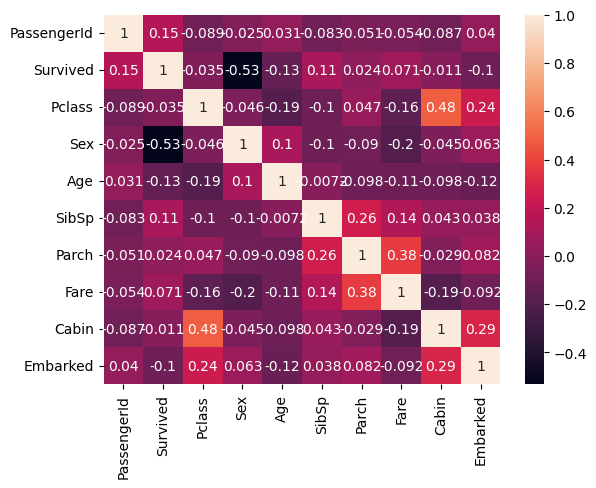

In [29]:
# Checking the correlation between each column

numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

We want to understand the relationship between survival, age, sex and ticket class. We will run multiple analyses to give us that insight.

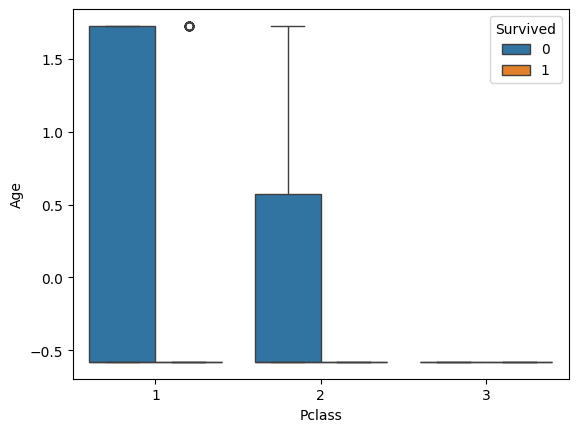

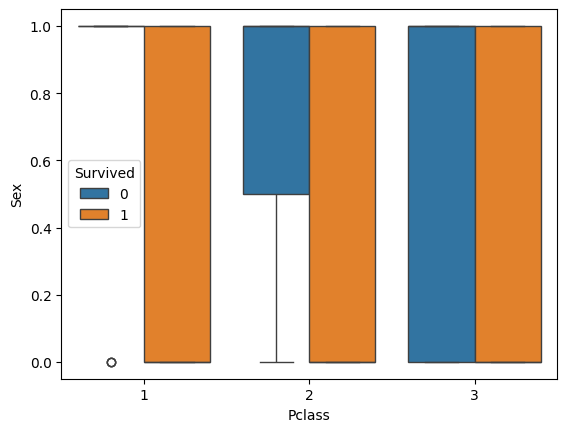

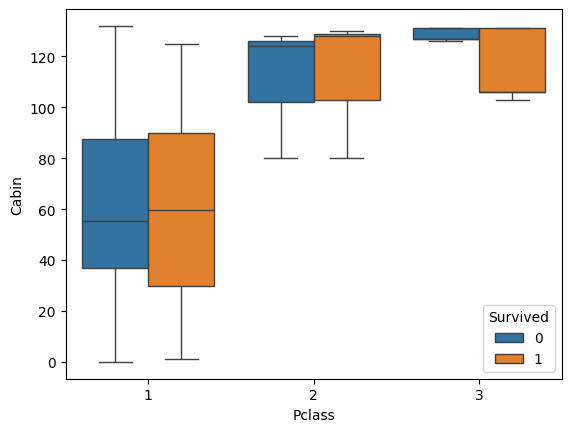

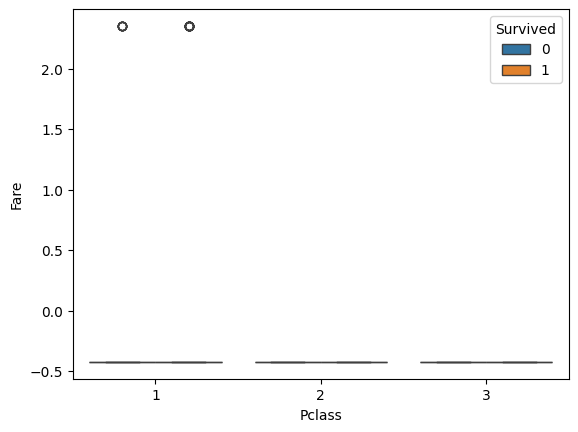

In [78]:
# We look at the relationship between survival, ticket class, fare, age and sex.

sns.boxplot(x="Pclass", y="Age", hue="Survived", data=df)
plt.show()

sns.boxplot(x="Pclass", y="Sex", hue="Survived", data=df)
plt.show()

sns.boxplot(x="Pclass", y="Cabin", hue="Survived", data=df)
plt.show()

sns.boxplot(x="Pclass", y="Fare", hue="Survived", data=df)
plt.show()

Distinguishing the most important determining factor in survival, using two methods of display.

In [79]:
# First, we create a new DataFrame with only the relevant columns.

survival_df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

# Then we perform chi-square tests to check for independence between survival and each variable.

for col in survival_df.columns[1:]:
  contingency_table = pd.crosstab(survival_df['Survived'], survival_df[col])
  chi2, p, _, _ = stats.chi2_contingency(contingency_table)
  print(f"Chi-square test for {col}: chi2={chi2:.2f}, p={p:.4f}")

Chi-square test for Pclass: chi2=2.46, p=0.2925
Chi-square test for Sex: chi2=49.63, p=0.0000
Chi-square test for Age: chi2=2.57, p=0.1088
Chi-square test for Fare: chi2=0.54, p=0.4623


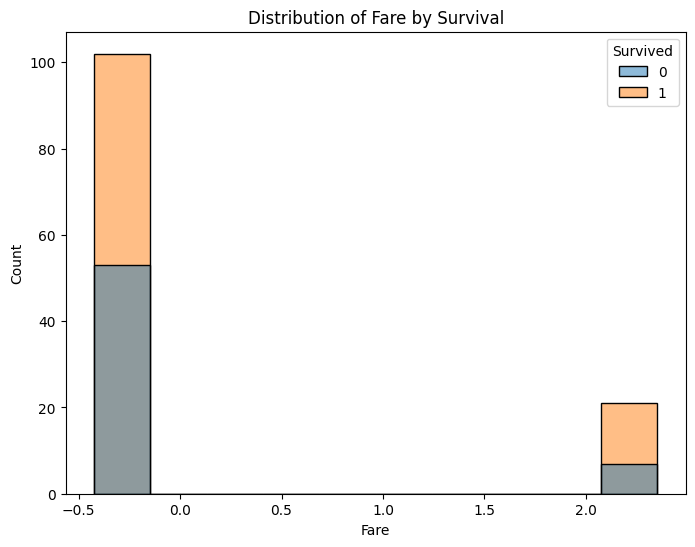

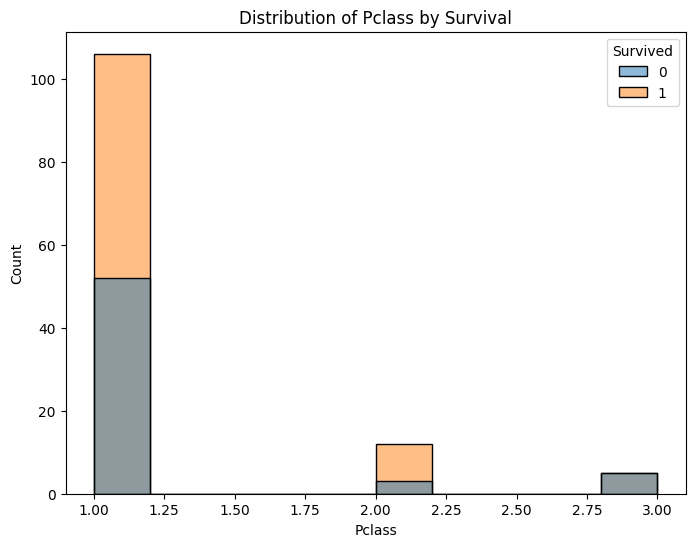

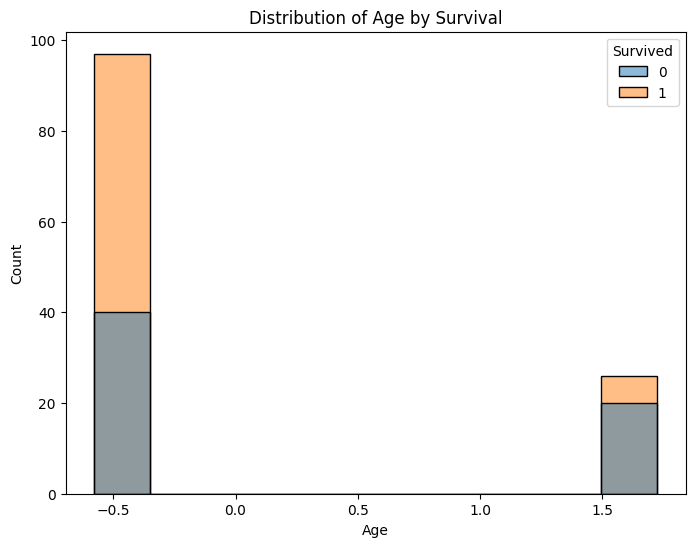

In [80]:
# We can also calculate the correlation between each variable and survival.

correlation = survival_df.corr()['Survived'].sort_values(ascending=False)

# Select the most important variables.

important_variables = correlation[1:4].index.tolist()

# Create a histogram for each important variable.

for variable in important_variables:
  plt.figure(figsize=(8, 6))
  sns.histplot(data=survival_df, x=variable, hue='Survived', bins=10)
  plt.title(f'Distribution of {variable} by Survival')
  plt.xlabel(variable)
  plt.ylabel('Count')
  plt.show()

Analysing the plausible rescue attempts using class, sex, age and fare to understand the eventual outcome of the survival rate.

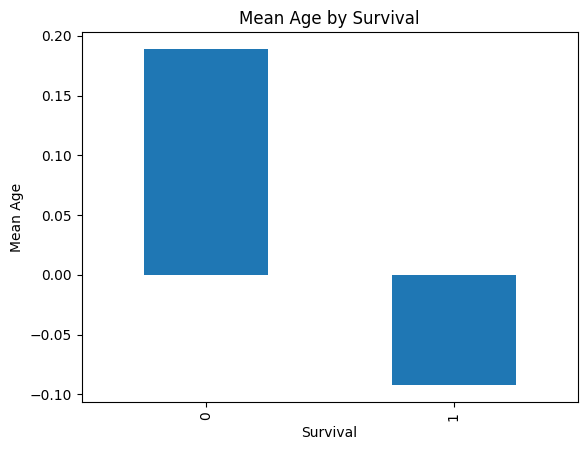

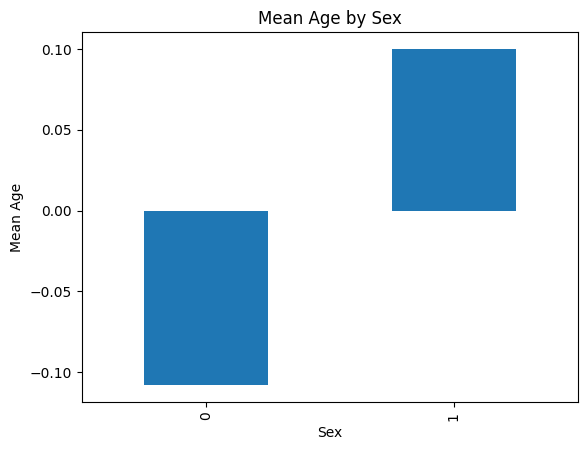

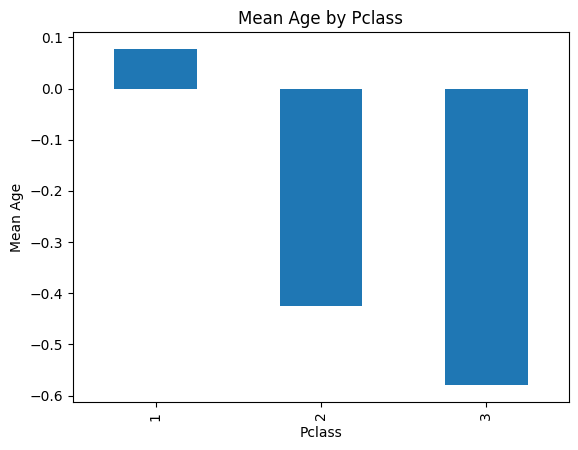

In [81]:
# Create a new DataFrame with only the relevant columns.

survival_df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

# Group the data by survival and calculate the mean age for each group.

mean_age_by_survival = survival_df.groupby('Survived')['Age'].mean()

# Create a bar chart to visualize the results.

mean_age_by_survival.plot(kind='bar')
plt.title('Mean Age by Survival')
plt.xlabel('Survival')
plt.ylabel('Mean Age')
plt.show()

# Repeat the above steps for sex and Pclass.

mean_age_by_sex = survival_df.groupby('Sex')['Age'].mean()
mean_age_by_sex.plot(kind='bar')
plt.title('Mean Age by Sex')
plt.xlabel('Sex')
plt.ylabel('Mean Age')
plt.show()

mean_age_by_pclass = survival_df.groupby('Pclass')['Age'].mean()
mean_age_by_pclass.plot(kind='bar')
plt.title('Mean Age by Pclass')
plt.xlabel('Pclass')
plt.ylabel('Mean Age')
plt.show()


**Conclusions:**

The EDA on the Titanic dataset revealed several interesting insights. For example, we found that the majority of passengers were male, the average age of passengers was 29 years old, and the most common ticket class was third class. We also found that there was a strong relationship between survival and ticket class, with passengers in first class being more likely to survive than passengers in third class.

**Further Analysis:**

The EDA on the Titanic dataset can be used to inform further analysis. For example, we could use the data to build a model to predict passenger survival. We could also use the data to identify factors that contributed to the sinking of the Titanic.
